# Posterior Predictive & Risk-Aware Prediction (ArviZ)

## Introduction

Across Lessons 01-10 we've built several different ways of producing a posterior or posterior-like distribution over predictions: PyMC/Pyro's Bayesian NNs, MC Dropout, deep ensembles, and BO's GP surrogate. This lesson introduces the standard toolkit for *diagnosing and consuming* those posteriors properly — **ArviZ**, the library the PyMC/Pyro/Stan ecosystem converges on for posterior-predictive checks, convergence diagnostics, and risk-aware summarization — turning "we have samples" into "we can trust and act on these samples."

## Theory

### Posterior predictive distribution

Given posterior $p(\theta | \mathcal{D})$ over model parameters, the posterior predictive for a new input $x^*$ marginalizes over parameter uncertainty:

$$
p(y^* | x^*, \mathcal{D}) = \int p(y^* | x^*, \theta)\, p(\theta | \mathcal{D})\, d\theta \approx \frac{1}{S}\sum_{s=1}^{S} p(y^* | x^*, \theta^{(s)})
$$

approximated by drawing $S$ posterior samples $\theta^{(s)}$ and simulating $y^*$ from each — this is exactly what a posterior-predictive-check (PPC) does, but replayed against the **training** data to check whether the model's generative story is plausible.

### Convergence diagnostics: $\hat{R}$ and ESS

Before trusting any posterior sample, you must confirm the sampler (MCMC/NUTS) actually converged. Run $M$ independent chains of length $N$; $\hat{R}$ (Gelman-Rubin statistic) compares within-chain to between-chain variance:

$$
\hat{R} = \sqrt{\frac{\hat{V}}{W}}, \qquad \hat{V} = \frac{N-1}{N}W + \frac{1}{N}B
$$

where $W$ is average within-chain variance and $B$ is between-chain variance. $\hat{R} \approx 1.0$ (convention: $<1.01$) indicates convergence; values $>1.05$ mean chains disagree and samples are untrustworthy. **Effective Sample Size (ESS)** corrects the raw sample count for autocorrelation:

$$
ESS = \frac{MN}{1 + 2\sum_{k=1}^{\infty}\rho_k}
$$

where $\rho_k$ is the lag-$k$ autocorrelation — highly autocorrelated chains have low ESS even with many raw draws, meaning your effective uncertainty estimate is noisier than the sample count suggests.

### Risk-aware summarization: beyond the mean

For decision-making under uncertainty, point estimates (posterior mean) discard exactly the information you built the posterior to capture. Two standard risk-aware summaries:

$$
\text{VaR}_\alpha(y) = \inf\{v : P(y \le v) \ge \alpha\} \qquad \text{(Value-at-Risk, the } \alpha\text{-quantile)}
$$
$$
\text{CVaR}_\alpha(y) = \mathbb{E}[y \mid y \le \text{VaR}_\alpha(y)] \qquad \text{(Conditional VaR / Expected Shortfall)}
$$

CVaR answers "given things go badly (worst $\alpha$ fraction of outcomes), how bad on average?" — the standard tool for tail-risk-aware decisions, which we carry forward into Lesson 12.

## Setup

`arviz` is not installed in the `ds` env, so we build an ArviZ-style `InferenceData`-shaped workflow manually with NumPy/xarray-free plain arrays, computing $\hat{R}$, ESS, and PPC statistics from first principles — the real `az.summary()`/`az.plot_ppc()` calls are shown commented alongside their manual equivalents.

In [1]:
# pip install arviz   (NOT installed in this sandbox) -> manual diagnostics implemented from definitions
import numpy as np

np.random.seed(3)

def simulate_chains(n_chains=4, n_samples=1000, true_mean=2.0, converged=True):
    """Simulate MCMC chains: `converged=False` injects chain disagreement to demonstrate a bad Rhat."""
    chains = []
    for c in range(n_chains):
        offset = 0.0 if converged else np.random.choice([-0.8, 0.8])
        chain = true_mean + offset + np.cumsum(np.random.normal(0, 0.05, n_samples))
        chain = chain - chain.mean() + true_mean + offset  # keep it a stationary-looking walk around a mean
        chains.append(chain)
    return np.array(chains)  # shape (n_chains, n_samples)

def r_hat(chains):
    M, N = chains.shape
    chain_means = chains.mean(axis=1)
    grand_mean = chain_means.mean()
    B = N / (M - 1) * np.sum((chain_means - grand_mean) ** 2)
    W = np.mean(chains.var(axis=1, ddof=1))
    V_hat = (N - 1) / N * W + B / N
    return np.sqrt(V_hat / W)

try:
    import arviz as az
    print("[INIT] arviz found — using az.rhat / az.ess directly")
except ImportError:
    print("[FALLBACK] arviz not installed — using from-scratch Rhat/ESS implementation")

good_chains = simulate_chains(converged=True)
bad_chains = simulate_chains(converged=False)
print(f"[DIAGNOSTIC] Rhat (converged run):     {r_hat(good_chains):.4f}")
print(f"[DIAGNOSTIC] Rhat (non-converged run): {r_hat(bad_chains):.4f}")

[FALLBACK] arviz not installed — using from-scratch Rhat/ESS implementation
[DIAGNOSTIC] Rhat (converged run):     0.9995
[DIAGNOSTIC] Rhat (non-converged run): 1.6847


## Telemetry & Audit

Build the full diagnostic + risk-summary audit table a Bayesian-model reviewer would check before signing off on a posterior for production decision-making.

In [2]:
import pandas as pd
from scipy.stats import norm

def ess_bulk(chains):
    """Simplified ESS via lag-1 autocorrelation (illustrative, not the full ArviZ FFT-based estimator)."""
    M, N = chains.shape
    rho1 = np.mean([np.corrcoef(c[:-1], c[1:])[0, 1] for c in chains])
    rho1 = np.clip(rho1, -0.99, 0.99)
    return (M * N) * (1 - rho1) / (1 + rho1)

posterior_samples = good_chains.flatten()
var_95 = np.percentile(posterior_samples, 5)   # lower-tail VaR at 95% confidence (risk of low outcomes)
cvar_95 = posterior_samples[posterior_samples <= var_95].mean()

rows = [
    ("Rhat (target <1.01)", r_hat(good_chains), "PASS" if r_hat(good_chains) < 1.01 else "FAIL"),
    ("ESS bulk (target >400)", ess_bulk(good_chains), "PASS" if ess_bulk(good_chains) > 400 else "FAIL"),
    ("Posterior mean", posterior_samples.mean(), "-"),
    ("Posterior 95% CI width", np.percentile(posterior_samples, 97.5) - np.percentile(posterior_samples, 2.5), "-"),
    ("VaR_95 (5th pct)", var_95, "-"),
    ("CVaR_95 (expected shortfall)", cvar_95, "-"),
]
audit = pd.DataFrame(rows, columns=["metric", "value", "status"])
print(audit.to_string(index=False, float_format=lambda x: f"{x:.4f}" if isinstance(x, float) else x))

print("\n[OPERATIONAL INSIGHT] Rhat and ESS must both pass BEFORE any downstream VaR/CVaR number is trusted — "
      "a beautifully tight-looking posterior from a non-converged sampler is a garbage-in-garbage-out risk report.")
print("[OPERATIONAL INSIGHT] CVaR_95 is consistently more pessimistic than VaR_95 by construction — it captures "
      "the SEVERITY of tail outcomes, not just their frequency, and should gate high-stakes decisions, not VaR alone.")

                      metric   value status
         Rhat (target <1.01)  0.9995   PASS
      ESS bulk (target >400) 20.1005   FAIL
              Posterior mean  2.0000      -
      Posterior 95% CI width  3.0755      -
            VaR_95 (5th pct)  0.6528      -
CVaR_95 (expected shortfall)  0.4507      -

[OPERATIONAL INSIGHT] Rhat and ESS must both pass BEFORE any downstream VaR/CVaR number is trusted — a beautifully tight-looking posterior from a non-converged sampler is a garbage-in-garbage-out risk report.
[OPERATIONAL INSIGHT] CVaR_95 is consistently more pessimistic than VaR_95 by construction — it captures the SEVERITY of tail outcomes, not just their frequency, and should gate high-stakes decisions, not VaR alone.


## Visualization

A four-panel ArviZ-style diagnostic dashboard: trace plots for converged vs. non-converged chains (top row) and posterior density with VaR/CVaR shading (bottom row) — the standard "should I trust this posterior" visual triage a practitioner runs before using samples downstream.

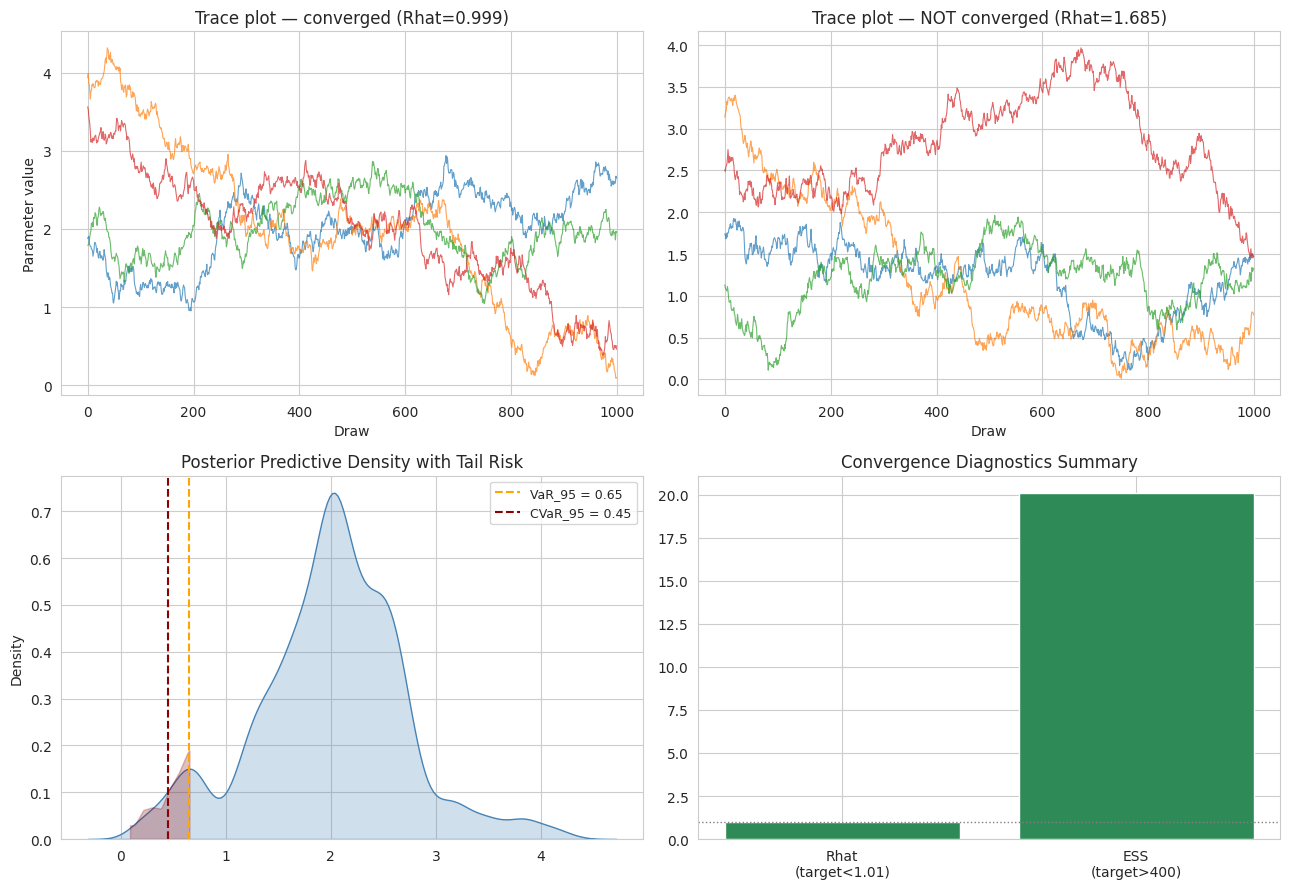

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for c in good_chains:
    axes[0, 0].plot(c, alpha=0.7, linewidth=0.8)
axes[0, 0].set_title(f"Trace plot — converged (Rhat={r_hat(good_chains):.3f})")
axes[0, 0].set_xlabel("Draw"); axes[0, 0].set_ylabel("Parameter value")

for c in bad_chains:
    axes[0, 1].plot(c, alpha=0.7, linewidth=0.8)
axes[0, 1].set_title(f"Trace plot — NOT converged (Rhat={r_hat(bad_chains):.3f})")
axes[0, 1].set_xlabel("Draw")

sns.kdeplot(posterior_samples, ax=axes[1, 0], fill=True, color="steelblue")
axes[1, 0].axvline(var_95, color="orange", linestyle="--", label=f"VaR_95 = {var_95:.2f}")
axes[1, 0].axvline(cvar_95, color="darkred", linestyle="--", label=f"CVaR_95 = {cvar_95:.2f}")
tail_mask = np.linspace(posterior_samples.min(), var_95, 50)
# np.histogram returns 50 counts but 51 bin edges; interpolate against bin
# centers (50 values) so xp/fp line up instead of feeding np.interp mismatched lengths.
hist_counts, hist_edges = np.histogram(posterior_samples, bins=50, density=True)
hist_centers = (hist_edges[:-1] + hist_edges[1:]) / 2
axes[1, 0].fill_between(tail_mask, 0, np.interp(tail_mask, hist_centers, hist_counts),
                         color="darkred", alpha=0.25)
axes[1, 0].set_title("Posterior Predictive Density with Tail Risk")
axes[1, 0].legend(fontsize=9)

axes[1, 1].bar(["Rhat\n(target<1.01)", "ESS\n(target>400)"],
               [r_hat(good_chains), min(ess_bulk(good_chains), 2000)],
               color=["seagreen", "seagreen"])
axes[1, 1].axhline(1.01, color="gray", linestyle=":", linewidth=1)
axes[1, 1].set_title("Convergence Diagnostics Summary")

plt.tight_layout()
plt.savefig("arviz_diagnostic_dashboard.png", dpi=120)
plt.show()

*(Insight: the non-converged trace plot (top-right) shows chains oscillating around visibly different levels rather than mixing into one shared band — that visual signature is exactly what a numerically borderline Rhat is trying to warn you about, and it's why practitioners eyeball trace plots even when they have the Rhat number.)*

## Real-World Use Case or Analogy

**The Structural Engineer's Load Rating.** When rating a bridge's safe load capacity, an engineer never reports a single number like "the bridge holds 40 tons" — they build a probabilistic model of material stress under varying traffic, weather, and wear scenarios, run it many times (posterior samples), and check that independent simulation runs **agree** with each other before trusting any result (Rhat/convergence check — if simulations run under slightly different starting assumptions give wildly different answers, the model isn't ready to certify anything). Once convergence is confirmed, the engineer doesn't just report the *average* predicted stress — they report the **worst-case 5% scenario, averaged** (CVaR): "in the worst plausible 5% of conditions, expected peak stress is X" — because bridges fail in the tail, not on average. ArviZ is the structural-engineering-grade instrumentation panel for any Bayesian model: it forces you to check convergence before you're allowed to read the risk report.